In [1]:
# import numpy as np
# import yaml

# from copy import deepcopy
# import numpy as np

# *from witch.cfg_loader import load_cfg

from witch.cfg_loader import load_cfg
from witch.fitter import *
from witch.objective import *

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
#Load in the data and models.
#TODO: right now this does some busy work loading the data and e.g. computing the noise map
#that it probably doesn't need to do if all you want to do is look at the model. Still it
#doesn't take very long and it's useful in other circumstances so I'm going to leave it in for the timebeing.

path = "/home/elebar/joint/WITCH/configs/xray_test/MOO1142_Xray.yaml"
cfg = load_config({}, path)
datasets, outdir, dset_names, metamodel = load_cfg(cfg)


mpi4py imported
nproc:,  1


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-END to 58839.579120 from DATE-END'. [astropy.wcs.wcs]


Outputs can be found in /mnt/welch/USERS/elebar/Reductions/X_MOO1142/model_ns/first_try/r_1-beta-amp-P0-r_s-beta
Map scale:  2.7008111


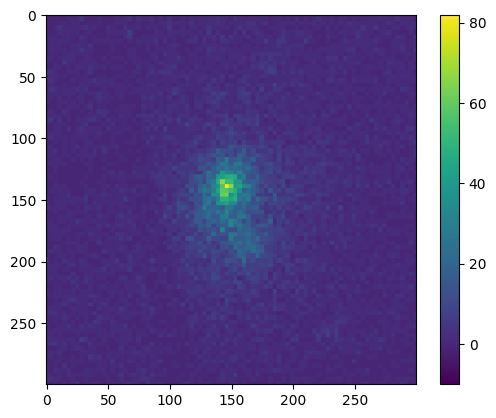

In [3]:
#plt.imshow(metamodel.datasets[0].metadata[0].beam_map)
#plt.colorbar()
#print(np.sum(metamodel.datasets[0].metadata[0].beam_map))

plt.imshow(datasets[0].datavec.solutions[0].data, vmin=-10)
plt.colorbar()

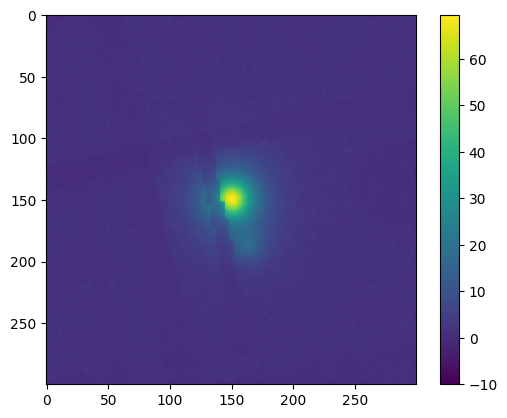

In [4]:
#To plot the full model on a given dataset, we use
#metamodel.model_grid(i), where i is the dataset of interest
#Plotting multiple datasets at the same time is in general non-sensical
#i.e. plotting x-ray and M2 simultaneously. However it can sometimes be 
#well defined (i.e. ACT+M2). In that case, you have to manually
# 1) get the maps in the same units 
# 2) get the maps in the same pixelation, probably by interpolation
#This is a pretty niche application so no example is given here
plt.imshow(metamodel.model_grid(0), vmin=-10)
plt.colorbar()



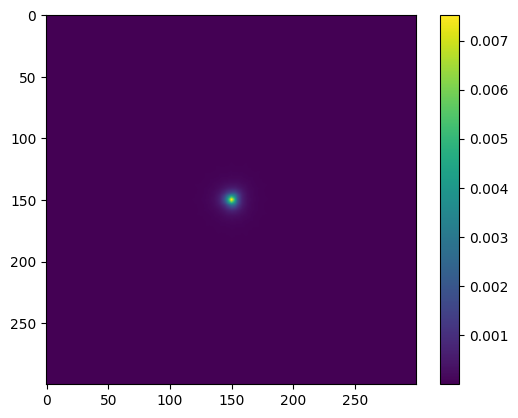

In [5]:
plt.imshow(metamodel.datasets[0].metadata[0].beam_map)
plt.colorbar()

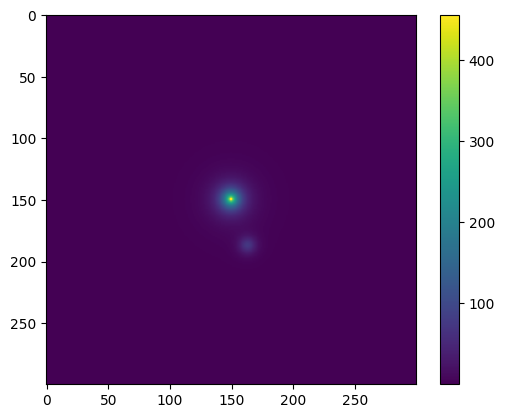

In [6]:
#If you want to only look at one component of the model, you can do the following:

plt.imshow(metamodel.models[0].model*metamodel.datasets[0].metadata[0].prefactor)
plt.colorbar()

In [7]:
#If you want to update parameters, do something like this

pars = np.array(deepcopy(metamodel.parameters))
pars[-1] = 1e-3

metamodel.update(pars, metamodel.errors, metamodel.chisq)

plt.imshow(metamodel.model_grid(0))
plt.colorbar()

AttributeError: 'MetaModel' object has no attribute 'errors'

In [ ]:
metamodel = fit_loop(metamodel, cfg, comm)

[resume] Not resuming from previous checkpoint
Compiling objective function


TypeError: ('input should be a Numpy array or something convertible into a float array', TracerArrayConversionError('The numpy.ndarray conversion method __array__() was called on traced array with shape float64[300,300]\nThe error occurred while tracing the function poisson_objective at /home/elebar/joint/WITCH/witch/objective.py:191 for jit. This concrete value was not available in Python because it depends on the values of the arguments metamodel[0][0][0][0][0][0], metamodel[0][0][0][0][1][0], metamodel[0][0][0][0][2][0], metamodel[0][0][0][0][3][0], metamodel[0][0][0][0][4][0], metamodel[0][0][0][0][5][0], metamodel[0][0][0][0][6][0], metamodel[0][0][0][1][0][0], metamodel[0][0][0][1][1][0], metamodel[0][0][0][1][2][0], metamodel[0][0][0][1][3][0], metamodel[0][0][0][1][4][0], metamodel[0][0][0][1][5][0], metamodel[0][0][0][1][6][0], metamodel[0][0][0][1][7][0], metamodel[0][0][0][1][8][0], metamodel[0][0][1][0], metamodel[0][0][1][1], metamodel[0][0][1][2], metamodel[0][0][1][3], m

In [ ]:
chisq, *_ = joint_objective(metamodel)

TypeError: ('input should be a Numpy array or something convertible into a float array', TracerArrayConversionError('The numpy.ndarray conversion method __array__() was called on traced array with shape float64[300,300]\nThe error occurred while tracing the function poisson_objective at /home/elebar/joint/WITCH/witch/objective.py:191 for jit. This concrete value was not available in Python because it depends on the values of the arguments metamodel[0][0][0][0][0][0], metamodel[0][0][0][0][1][0], metamodel[0][0][0][0][2][0], metamodel[0][0][0][0][3][0], metamodel[0][0][0][0][4][0], metamodel[0][0][0][0][5][0], metamodel[0][0][0][0][6][0], metamodel[0][0][0][1][0][0], metamodel[0][0][0][1][1][0], metamodel[0][0][0][1][2][0], metamodel[0][0][0][1][3][0], metamodel[0][0][0][1][4][0], metamodel[0][0][0][1][5][0], metamodel[0][0][0][1][6][0], metamodel[0][0][0][1][7][0], metamodel[0][0][0][1][8][0], metamodel[0][0][1][0], metamodel[0][0][1][1], metamodel[0][0][1][2], metamodel[0][0][1][3], m

In [ ]:
do_loglike, do_grad, do_curve = True, True, True
dataset_ind=0
# _loglike, _grad, _curve = poisson_objective(
#     metamodel,
#    dataset_ind,
#    do_loglike,
#    do_grad,
#    do_curve,
# )

npar = len(metamodel.parameters)
loglike = jnp.array(0)
grad = jnp.zeros(npar)
curve = jnp.zeros((npar, npar))

zero = jnp.zeros((1, 1))
only_loglike = not (do_grad or do_curve)

dataset = metamodel.datasets[dataset_ind]
if dataset.mode not in ["tod", "map"]:
    raise ValueError("Invalid mode")
for i, data in enumerate(dataset.datavec):
    pred_dat = metamodel.model_proj(dataset_ind, i)
    if only_loglike:
        grad_dat = zero
    else:
        grad_dat = metamodel.model_grad_proj(dataset_ind, i)


TypeError: ('input should be a Numpy array or something convertible into a float array', TracerArrayConversionError('The numpy.ndarray conversion method __array__() was called on traced array with shape float64[300,300]\nThis BatchTracer with object id 140173105310768 was created on line:\n  /home/elebar/joint/WITCH/witch/external/xray/funcs.py:227:47 (ExpConvProj.apply_grad)\nSee https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError'))

In [ ]:
def _project(ip, x, y, xyz):
    return wu.bilinear_interp(
        x.ravel(), y.ravel(), xyz[0].ravel(), xyz[1].ravel(), ip
    ).reshape(x.shape)
_project_vectorized = jax.vmap(_project, in_axes=(0, None, None, None))
for datavec_ind, data in enumerate(dataset.datavec):
    dset =datasets[dataset_ind]
    m_map = metamodel.model_map[dataset_ind]
    md_map = metamodel.metadata_map[dataset_ind]
    data = dset.datavec[datavec_ind]
    if dset.mode == "tod":
        x = data.x
        y = data.y
    else:
        x, y = data.xy
    x = x * wu.rad_to_arcsec
    y = y * wu.rad_to_arcsec
    proj_grad = jnp.zeros(metamodel.parameters.shape + x.shape)
    for i in m_map:
        model = metamodel.models[i]
        md = md_map[i]
        par_map = metamodel.parameter_map[i]
        ip_grad = model.model_grad[1]
        for md_idx in md:
            ip_grad = dset.metadata[md_idx].apply_grad(ip_grad)
        _proj_grad = _project_vectorized(ip_grad, x, y, model.xyz)
        for md_idx in md:
            _proj_grad = dset.metadata[md_idx].apply_grad_proj(_proj_grad)
        proj_grad = proj_grad.at[jnp.array(par_map)].add(_proj_grad)

TypeError: ('input should be a Numpy array or something convertible into a float array', TracerArrayConversionError('The numpy.ndarray conversion method __array__() was called on traced array with shape float64[300,300]\nThis BatchTracer with object id 140171628609072 was created on line:\n  /home/elebar/joint/WITCH/witch/external/xray/funcs.py:227:47 (ExpConvProj.apply_grad)\nSee https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError'))